# 卡尔曼滤波在配对交易中的进阶应用 (Kalman Filter Applications)

在前面的回测示例中，我们使用 OLS 回归在整个历史数据上计算了一个固定的对冲比例 (Hedge Ratio, $\beta$)。

或者在稍进阶的应用中，我们会使用“滚动窗口 OLS (Rolling OLS)”来动态更新 $\beta$。

但这两种方法都有严重的缺陷：
1.  **固定 $\beta$ 引入了“未来函数 (Lookahead Bias)”**：用包含 2023 年的数据算出的 $\beta$ 去交易 2021 年的日子，显然作弊。
2.  **滚动窗口 OLS 噪音大且滞后**：窗口设为几天？当早期发生突变并从窗口滑出时，OLS 的 $\beta$ 会发生剧烈的毛刺跳跃 (Ghost Effects)。

为了解决这个问题，机构级量化研究通常引入**卡尔曼滤波 (Kalman Filter)**。

## 什么是卡尔曼滤波器？

卡尔曼滤波是一种**动态线性模型 (DLM)** 或状态空间模型。
在嘈杂的数据流中，它能不断读取新的测量数据流连续更新自身以估计信号系统的当前状态。
在金融配对交易中，系统的“隐藏状态”就是真实地随时间漂移的**对冲比例 $\beta_t$** 及其误差方差。

*   **预测步 (Predict):** 基于昨日已知的 $\beta_{t-1}$，预测今天的 $\beta_t$。
*   **更新步 (Update):** 今天收盘看到了真实的 $Y_t$ 和 $X_t$。通过比较实际的 $Y$ 和用预测 $\beta$ 算出的预期 $Y$，滤波器会对 $\beta_t$ 进行修正。

## 卡尔曼滤波在量化中的优势

1. **绝对没有未来信息**：只使用当下已知数据递推，避免 Lookahead bias。
2. **无需指定滞后的固定窗口**：自带指数衰减记忆机制，杜绝“Ghost Effects”。
3. **内置不确定性估计**：除了点估计 $\beta$，还有**协方差矩阵**代表“自信程度”，可用于头寸调节。


In [1]:
!pip install pykalman


In [2]:
import numpy as np
import pandas as pd
from pykalman import KalmanFilter
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

def kalman_filter_beta(y, x):
    """
    使用卡尔曼滤波器动态估计 Y 和 X 之间的对冲比例 Beta。
    观测方程： y_t = alpha_t + beta_t * x_t + v_t
    状态方程：[alpha_t, beta_t] = [alpha_{t-1}, beta_{t-1}] + w_t
    """
    # 构造观测矩阵 (Observation Matrix)，加上一列全为1代表常数项 Alpha
    obs_mat = sm.add_constant(x.values)[:, np.newaxis] 

    # 初始化卡尔曼滤波器
    kf = KalmanFilter(
        n_dim_obs=1,             # 观测维度，只有 y 
        n_dim_state=2,           # 状态维度，[alpha, beta]
        initial_state_mean=np.zeros(2), 
        initial_state_covariance=np.ones((2, 2)),
        transition_matrices=np.eye(2),       # [alpha_t, beta_t] 等待昨日的值
        observation_matrices=obs_mat,        # H 矩阵: [1, x_t]
        observation_covariance=1.0,          # R 观测噪声方差 (需调参)
        transition_covariance=np.eye(2) * 0.01 # Q 状态漂移方差 (需调参)
    )

    # 运行滤波器 (使用 filter 进行在线递推估计，不用 smooth，以避免未来函数)
    state_means, _ = kf.filter(y.values)
    
    # 返回分离出的动态 Alpha 序列和 Beta 序列
    dynamic_alpha = pd.Series(state_means[:, 0], index=y.index)
    dynamic_beta = pd.Series(state_means[:, 1], index=y.index)
    
    return dynamic_alpha, dynamic_beta

print("卡尔曼滤波引擎构建完毕。可以将产生的 dynamic_beta 替换此前固定的 Beta 进行 OOS 回测。")


卡尔曼滤波引擎构建完毕。可以将产生的 dynamic_beta 替换此前固定的 Beta 进行 OOS 回测。


In [3]:
import matplotlib.pyplot as plt

# 1. 设置系统自带的中文字体（这里使用黑体 SimHei）
plt.rcParams['font.sans-serif'] = ['SimHei']  # 如果你想用微软雅黑，可以改成 ['Microsoft YaHei']

# 2. 解决更换字体后，负号（-）显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

## 3. 实战：使用 Kalman Filter 动态追踪协整 Spread

我们将模拟一个环境，其中两只股票的对冲比例 $\beta$ 会随着时间发生一次“结构性漂变（Regime Shift）”。

*   **固定 OLS** 会取一根居中的平均线，导致两头都在亏钱。
*   **滚动 OLS** 反应迟缓且可能引发假突变。
*   **Kalman Filter** 能灵敏且平滑地追踪到 $\beta$ 的真实漂变。


无论市场如何变化，OLS 想用一个固定的 Beta = -4.2584 来解释整个历史。


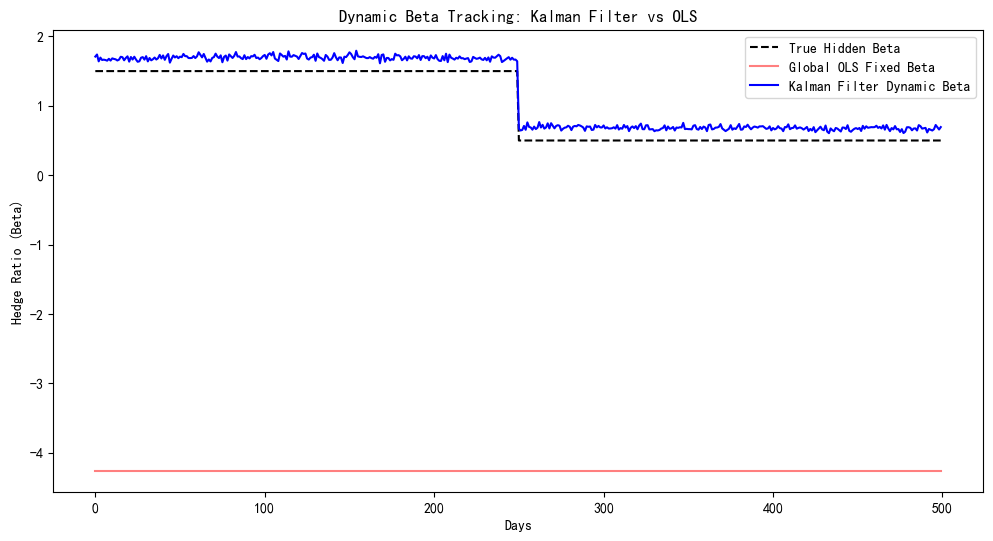

In [5]:
import matplotlib.pyplot as plt

np.random.seed(42)
# 模拟股票 X 的价格走势
x_returns = np.random.normal(0, 1, 500)
x_prices = np.cumsum(x_returns) + 100
stock_x = pd.Series(x_prices)

# 模拟股票 Y，它的 Beta 发生了一次结构性漂移
# 前 250 天 Beta = 1.5, 后 250 天 Beta = 0.5
true_betas = np.concatenate([np.ones(250) * 1.5, np.ones(250) * 0.5])
true_alphas = np.ones(500) * 20.0

y_prices = true_alphas + true_betas * x_prices + np.random.normal(0, 3, 500) # 加上噪音 (平稳的 Spread)
stock_y = pd.Series(y_prices)

# 1. 传统方法：使用全局 OLS 拟合
fixed_ols_model = sm.OLS(stock_y, sm.add_constant(stock_x)).fit()
fixed_beta = fixed_ols_model.params.iloc[1]
print(f"无论市场如何变化，OLS 想用一个固定的 Beta = {fixed_beta:.4f} 来解释整个历史。")

# 2. 现代方法：卡尔曼滤波动态追踪
dynamic_alpha, dynamic_beta = kalman_filter_beta(stock_y, stock_x)

# --- 绘图展示动态 Beta 的追踪效果 ---
plt.figure(figsize=(12, 6))
plt.plot(true_betas, label='True Hidden Beta', color='black', linestyle='--')
plt.plot([fixed_beta]*500, label='Global OLS Fixed Beta', color='red', alpha=0.5)
plt.plot(dynamic_beta.values, label='Kalman Filter Dynamic Beta', color='blue')
plt.title('Dynamic Beta Tracking: Kalman Filter vs OLS')
plt.xlabel('Days')
plt.ylabel('Hedge Ratio (Beta)')
plt.legend()
plt.show()


如上图所示，当市场发生**制度转换 (Regime Shift)** 时，全局 OLS 是完全失效的（用红线去套前后的黑线）。而卡尔曼滤波器在短暂的适应期后，平滑地追踪到了新的真实 Beta。


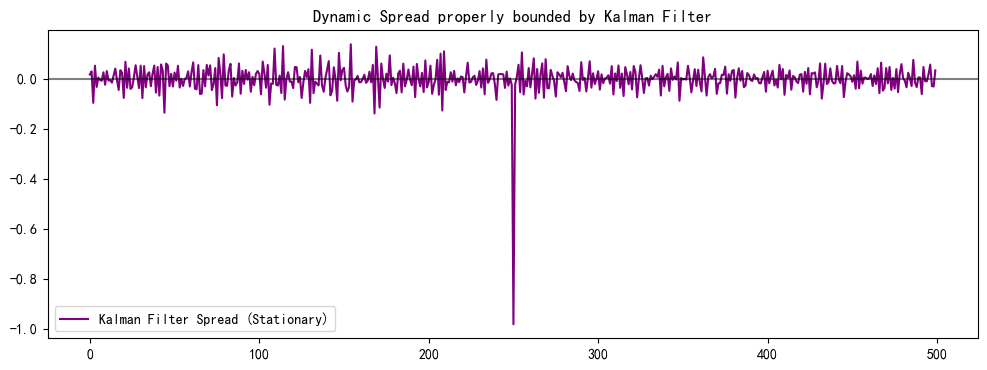

In [6]:
# 基于卡尔曼滤波器的动态 Spread 计算
# Spread_t = Y_t - (alpha_t + beta_t * X_t)
kalman_spread = stock_y - (dynamic_alpha + dynamic_beta * stock_x)

# 如果我们画出这个动态 Spread
plt.figure(figsize=(12, 4))
plt.plot(kalman_spread.index, kalman_spread.values, color='purple', label='Kalman Filter Spread (Stationary)')
plt.axhline(0, color='black', alpha=0.5)
plt.title('Dynamic Spread properly bounded by Kalman Filter')
plt.legend()
plt.show()


这极大降低了历史过拟合参数（Overfitting）的可能性，并增强了策略在实盘未知数据上的鲁棒性。

## 本章结语

配对交易绝不是拿历史均线套未来的简单游戏。

*   在 `06_pairs_trading_strategy.ipynb` 中，为了演示逻辑框架，我们假设了 $\beta$ 是固定不变且前后眼通天的。这种 **Lookahead Bias** 是毁掉量化新手的罪魁祸首。
*   在本章中，引入了动态线性模型（卡尔曼滤波器），真正实现了“利用 $t-1$ 的信息来调整 $t$ 取值的滤波器逻辑”，剥离了未来函数的影响。

至此，我们完成了**统计套利**中最硬核也是最经典的代码实战环节。在随后的章节中（`Phase 4` 和 `Phase 5`），我们将视野扩张到全市场范围的多因子选股模型体系中。


## 🎯 练习

1. 修改卡尔曼滤波器的 `transition_covariance` 参数（Q 矩阵），观察它对 Beta 追踪灵敏度的影响。
2. 将上一章的配对交易策略整合到卡尔曼滤波动态 Spread 上，对比新旧回测的夏普比率。
3. 研究 `pykalman` 的 `smooth()` 与 `filter()` 的区别，为什么金融应用中绝对不能用 `smooth()`？

---
**下一节** → `../05_portfolio/04_factor_analysis.ipynb`
